In [129]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn


In [130]:
weight = 0.7
bias = 0.3

# create a range of values between 0 and 1, 100 values
start = 0
end = 1
step = 0.02

torch.manual_seed(42) #set the random seed for reproducibility

X = torch.arange(start, end, step).unsqueeze(1) #extra dimension for the batch size
y = weight * X + bias + torch.randn(X.shape) * 0.01 #add some noise to the data

In [131]:
# ## split the data into training and test sets
# train_split = int(0.7 * len(X))
# X_train, y_train = X[:train_split], y[:train_split]
# X_valid, y_valid = X[train_split:train_split + int(0.15 * len(X))], y[train_split:train_split + int(0.15 * len(X))]
# X_test, y_test = X[train_split + int(0.15 * len(X)):], y[train_split + int(0.15 * len(X)):]

In [132]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [133]:
# scikit train test split next time will do

In [134]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [135]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(8, 5))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=5, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=5, label="Testing data")

    if predictions is not None:
        # Plot predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=5, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14});

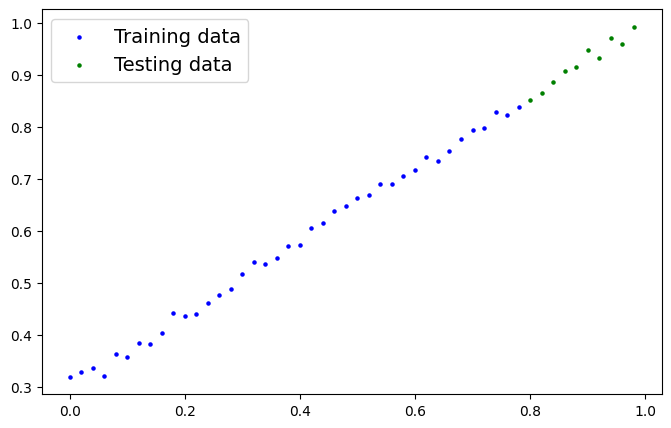

In [136]:
plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test)

In [137]:
#create a linear regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, #first randomly initialized weight
                                                requires_grad=True, #gradient optimization
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        ## forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias #linear regression formula
        

    # subclass the nn.Module class to create a linear regression model with weights and bias as parameters. The forward method defines the computation of the model, which is a linear equation.
    # forward needs updated 

In [138]:
#gradient descent and backpropagation to update the weights and bias of the model based on the loss function. The optimizer will be used to perform the optimization step.

## Pytorch models essentials

* torch.nn - contains all of the buildings for computational graphs
* torch.nn.Parameter - what parameters should model optimize and learn
* torch.nn.Module - The base class for all NN modules
* torch.optim - various optimization algorithms

In [139]:
# torchvision is a library that provides pre-trained models and datasets for computer vision tasks. It can be used to load and preprocess images, as well as to train and evaluate models.
# torch.utils.data_Dataset is a PyTorch class that provides an interface for loading and processing datasets. It can be used to create custom datasets, as well as to load and preprocess existing datasets.
# torch.utils.data.DataLoader is a PyTorch class that provides an interface for loading and batching datasets. It can be used to create data loaders for training and evaluation, as well as to shuffle and augment the data.
# torch.metrics is a PyTorch module that provides a set of metrics for evaluating the performance of models. It can be used to compute accuracy, precision, recall, F1 score, and other metrics for classification and regression tasks.

In [140]:
# linear regression model is a simple model that can be used for regression tasks. It can be trained using gradient descent and backpropagation to update the weights and bias of the model based on the loss function. The optimizer will be used to perform the optimization step.
torch.manual_seed(42)
# create a linear regression model instance
model_0 = LinearRegressionModel()

In [141]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [142]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [143]:
### make predictions with the untrained model

with torch.inference_mode(): #removes the gradient tracking and speeds up the computation
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

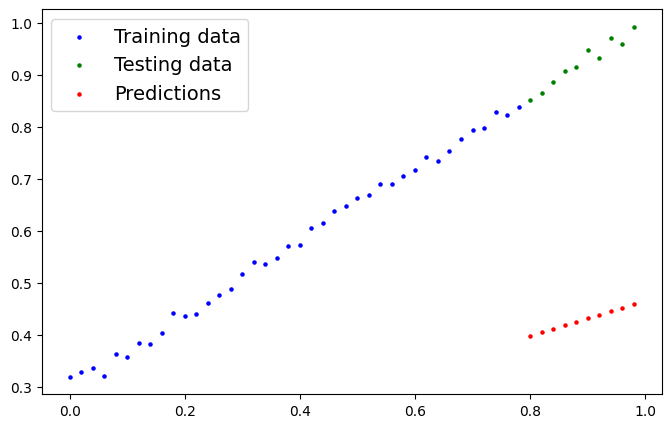

In [144]:
plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_preds)


In [145]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

# train model

 the model using gradient descent and backpropagation to update the weights and bias of the model based on the loss function. The optimizer will be used to perform the optimization step.

The whole idea is to move from random guess to fair representation

how wrong or how fair - we need loss function

In [146]:
MAE_loss = torch.mean(torch.abs(y_test - y_preds))
MAE_loss

tensor(0.4948, grad_fn=<MeanBackward0>)

In [147]:
loss_fn = nn.L1Loss() #mean absolute error loss function
loss_fn

L1Loss()

In [148]:
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01 #learning rate - hyperparameter that controls the step size of the optimization algorithm
                            )

## build a training loop and test loop

0. loop through the data (look several times just to check)
1. Forward pass (involves data moving though our model)
2. Calculate the loss - (y_pred - y_actual)
3. Optimizer zero grad
4. Loss backward (backward propagation) - chain rule. Calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step (minimize the gradient - **gradient descent**)

In [149]:
epoch_count = []
loss_values = []
test_loss_values = []

#0. loop through the data
epochs = 300 #1 loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train() # train model in PyTorch sets all parameters to require gradients and enables dropout and batch normalization layers (if any) to behave differently during training and evaluation. It also allows the model to update its parameters during backpropagation.

    # 1. forward pass
    y_pred = model_0(X_train)
    # 2. calculate the loss
    loss = loss_fn(y_pred, y_train)
    #print(f"Epoch: {epoch} | Loss: {loss:.5f}")
    # 3. zero the gradients
    optimizer.zero_grad() # sets all the gradients of the model parameters to zero. This is necessary because PyTorch accumulates gradients by default, so if we don't zero them out, the gradients from previous iterations will be added to the current gradients, leading to incorrect updates.
    # 4. backward pass
    loss.backward() # computes the gradients of the loss with respect to the model parameters using backpropagation. This is necessary for updating the model parameters during optimization.
    # 5. update the weights
    optimizer.step() # updates the model parameters using the gradients computed during the backward pass. This


    # test the model in evaluation mode
    model_0.eval() # set the model to evaluation mode and disables dropout and batch normalization layers (if any) to behave differently during training and evaluation. It also prevents the model from updating its parameters during backpropagation.
    with torch.inference_mode(): # disables gradient tracking and speeds up the computation. It also prevents the model from updating its parameters during backpropagation.
        # 1. do the forward pass
        test_pred = model_0(X_test)
        # 2. calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")
    

Epoch: 0 | Loss: 0.31400 | Test loss: 0.48137
Epoch: 10 | Loss: 0.19879 | Test loss: 0.34666
Epoch: 20 | Loss: 0.08886 | Test loss: 0.21723
Epoch: 30 | Loss: 0.05660 | Test loss: 0.14816
Epoch: 40 | Loss: 0.04740 | Test loss: 0.11278
Epoch: 50 | Loss: 0.04361 | Test loss: 0.09911
Epoch: 60 | Loss: 0.04012 | Test loss: 0.08809
Epoch: 70 | Loss: 0.03663 | Test loss: 0.07707
Epoch: 80 | Loss: 0.03314 | Test loss: 0.06605
Epoch: 90 | Loss: 0.02965 | Test loss: 0.05503
Epoch: 100 | Loss: 0.02617 | Test loss: 0.04471
Epoch: 110 | Loss: 0.02284 | Test loss: 0.03891
Epoch: 120 | Loss: 0.01977 | Test loss: 0.03253
Epoch: 130 | Loss: 0.01690 | Test loss: 0.02518
Epoch: 140 | Loss: 0.01413 | Test loss: 0.02175
Epoch: 150 | Loss: 0.01176 | Test loss: 0.01674
Epoch: 160 | Loss: 0.01014 | Test loss: 0.01128
Epoch: 170 | Loss: 0.00965 | Test loss: 0.01084
Epoch: 180 | Loss: 0.00933 | Test loss: 0.01053
Epoch: 190 | Loss: 0.00919 | Test loss: 0.01028
Epoch: 200 | Loss: 0.00917 | Test loss: 0.01009
Epo

In [150]:
model_0.state_dict() #view the model's parameters (weights and bias)

OrderedDict([('weights', tensor([0.6923])), ('bias', tensor([0.3048]))])

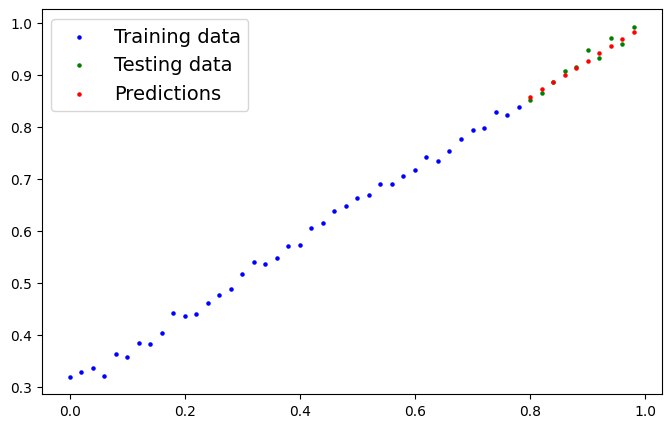

In [151]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_preds_new)

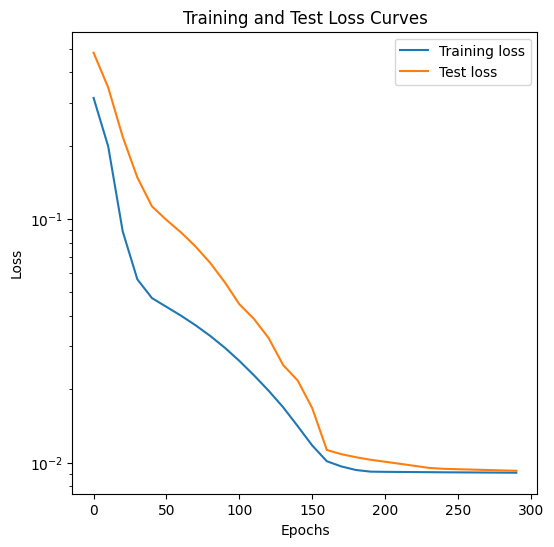

In [153]:
plt.figure(figsize=(6, 6))
plt.plot(epoch_count, loss_values, label="Training loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Test Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()

## Saving and loading model

* torch.save() - allows to save in pickle format
* torch.load() - allows to load a saved PyTorch object
* torch.nn.Module.load_state_dict() - save/load state dict

In [ ]:
#save the model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) #make the directory if it doesn't exist

# Save the model state dict
torch.save(model_0.state_dict(), MODEL_PATH / "model_0_state_dict.pth")